# Análise exploratória Telco Customer Churn
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Dataset com dados de uma empresa de telecomunicações que forneceu serviço de telefonia e internet para 7.043 clientes na Califórnia.

- Tamanho: 7.043 registros e 21 variáveis (colunas).
- Principais Atributos:
  - Dados Demográficos: Gênero, idade (idoso ou não), parceiros e dependentes.
  - Serviços Contratados: Linhas telefônicas, tipo de internet (DSL, Fibra ótica), segurança online, suporte técnico, streaming de TV e filmes
  - Informações Financeiras e Contratuais: Tempo de permanência (tenure), tipo de contrato (mensal, anual), método de pagamento, cobranças mensais (MonthlyCharges) e totais (TotalCharges).

**Importar bibliotecas e carregar dados**

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

file_path = 'data/WA_Fn-UseC_-Telco-Customer-Churn_Clean.csv'
data = pd.read_csv(file_path)
pd.set_option('display.max_columns', None)

**Salvar alterações no csv (Perigoso...)** 

In [2]:
# data.to_csv(r"data\WA_Fn-UseC_-Telco-Customer-Churn_Clean.csv", index=False)

# Descrição dos dados

Informações de clientes de uma empresa de telecomunicações, contendo dados demográficos, assinaturas de serviços, detalhes da conta, informações de faturamento e uma marcação **(flag)** de rotatividade **(churn)**, que indica se o cliente cancelou o serviço. Ele ajuda a analisar o comportamento do cliente e a identificar os principais fatores que contribuem para a evasão de clientes **(churn)**.

- **customerID** – Identificador exclusivo atribuído a cada cliente.
- **gender** – Gênero do cliente (Male/Female).
- **SeniorCitizen** – Indica se o cliente é idoso (0 = Não, 1 = Sim).
- **Partner** – Se o cliente tem um parceiro/companheiro (Yes/No).
- **Dependents** – Se o cliente possui dependentes (Yes/No).
- **tenure** – Número de meses que o cliente percontrata/contratou a empresa.
- **PhoneService** – Indica se o cliente possui serviço de telefonia (Yes/No).
- **MultipleLines** – Múltiplas linhas telefônicas.
- **InternetService** – Tipo de serviço de internet (DSL/Fiber optic/No internet service).
- **OnlineSecurity** – Status do serviço de segurança online.
- **OnlineBackup** – Status do serviço de backup online.
- **DeviceProtection** – Status do plano de proteção de dispositivos.
- **TechSupport** – Status do serviço de suporte técnico.
- **StreamingTV** – Acesso ao serviço de streaming de TV.
- **StreamingMovies** – Acesso ao serviço de streaming de filmes.
- **Contract** – Tipo de contrato do cliente (Month-to-month/One year/Two year).
- **PaperlessBilling** – Indica se o cliente utiliza faturamento digital (Yes/No).
- **PaymentMethod** – Forma de pagamento do cliente.
- **MonthlyCharges** – Valor cobrado mensalmente do cliente.
- **TotalCharges** – Total de despesas acumuladas pelo cliente.
- **Churn** – Indica se o cliente descontinuou/cancelou o serviço (Yes/No).

# 1. Visualização dos dados

In [3]:
# exibe a quantidade de linhas e colunas, junto de uma breve vizualisação dos dados
## data.head() - primeiras linhas | data.tail() - as últimas linhas

print(f"rows: {data.shape[0]} / columns {data.shape[1]}")
data.head()
#data.tail()

rows: 7043 / columns 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# exibe todas as colunas do dataset em string

data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
# os tipos de dados que compoem o dataset

#data.dtypes
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
# exibe apenas as colunas numéricas, isolando em int e float

num_col = data.select_dtypes(include=['float64','int64'])
num_col

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65
...,...,...,...,...
7038,0,24,84.80,1990.50
7039,0,72,103.20,7362.90
7040,0,11,29.60,346.45
7041,1,4,74.40,306.60


In [7]:
# separa as colunas do dataset que são do tipo objeto/string

cat_col = data.select_dtypes(include=['object'])
cat_col.columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [8]:
# estatísticas das colunas numéricas (média, mediana, desvio padrão, min/max)

data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [9]:
# vizualisação de valores nulos por coluna

#data.isnull()
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
# quantidade de valores preenchidos em cada coluna

data.count()

customerID          7043
gender              7043
SeniorCitizen       7043
Partner             7043
Dependents          7043
tenure              7043
PhoneService        7043
MultipleLines       7043
InternetService     7043
OnlineSecurity      7043
OnlineBackup        7043
DeviceProtection    7043
TechSupport         7043
StreamingTV         7043
StreamingMovies     7043
Contract            7043
PaperlessBilling    7043
PaymentMethod       7043
MonthlyCharges      7043
TotalCharges        7043
Churn               7043
dtype: int64

In [11]:
# distribuição de dados numericos e a frequencia de categorias

data.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043.000000,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2281.916928,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2265.270398,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,402.225000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3786.600000,NaN


In [12]:
# descritivas para dados do tipo string/objeto

data.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [13]:
# lista os valores unicos de cada coluna

list_it =['gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn']
for x in list_it:
  print(x)
  print(data[x].unique())
  print()

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingTV
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingMovies
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Contract
<StringArray>
['Month-to-month', 'One year', 'T

In [14]:
# exibir textos vazios (com espaço sendo contabilizado)

(data == " ").sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
tc = data[data['TotalCharges'] == " "]
print(tc[['tenure', 'MonthlyCharges', 'TotalCharges']])

# clientes novos recebem 0 e TotalCharges marca como vazio

Empty DataFrame
Columns: [tenure, MonthlyCharges, TotalCharges]
Index: []


**Corrigindo TotalCharges**

In [16]:
data.replace({" ": np.nan}, inplace=True)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [17]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [18]:
data['TotalCharges'].dtypes

dtype('float64')

In [19]:
data.duplicated().sum()

np.int64(0)

In [20]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

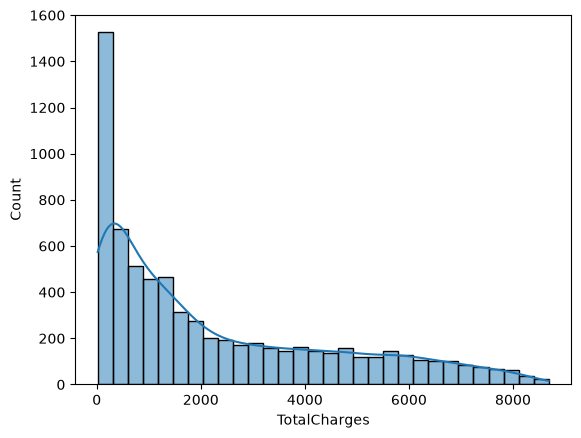

In [21]:
# testando gráfico
sns.histplot(data['TotalCharges'], bins=30, kde=True)
plt.show()

In [22]:
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

In [23]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [24]:
for x in list_it:
  print(x)
  print(data[x].unique())
  print()

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingTV
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingMovies
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Contract
<StringArray>
['Month-to-month', 'One year', 'T

# 2. Analises sobre os dados demográficos
### 1. Conhecendo o Perfil Demográfico da Nossa Base
Antes de cruzar os dados com os cancelamentos, buscamos entender quem são, de fato, os nossos clientes. 

Nesta etapa, geramos um panorama geral da distribuição demográfica analisando quatro variáveis: gênero, se o cliente é idoso (`SeniorCitizen`), se tem parceiro(a) (`Partner`) e se tem dependentes (`Dependents`). Isso nos dá uma "foto" de como a nossa carteira está composta hoje e ajuda a evitar conclusões precipitadas mais para frente.

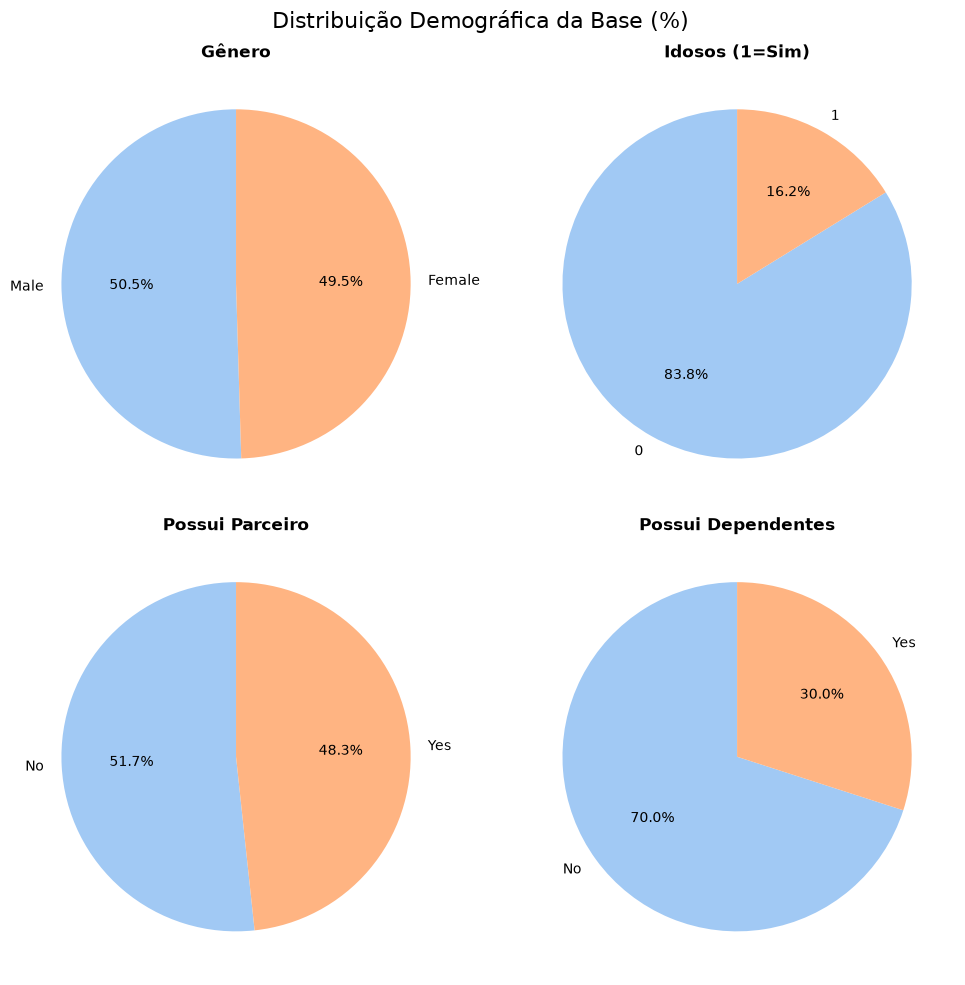

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
variaveis = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
titulos = ['Gênero', 'Idosos (1=Sim)', 'Possui Parceiro', 'Possui Dependentes']

for ax, var, titulo in zip(axes.flatten(), variaveis, titulos):
    contagem = data[var].value_counts()
    ax.pie(contagem, labels=contagem.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
    ax.set_title(titulo, fontweight='bold')

plt.suptitle("Distribuição Demográfica da Base (%)", fontsize=16)
plt.tight_layout()
plt.show()

### 2. Diagnóstico de Evasão: Onde estamos perdendo clientes?
Agora buscamos entender como esses perfis demográficos se comportam em relação ao cancelamento de serviços (`Churn`). 

Aqui, cruzamos as variáveis que acabamos de ver diretamente com a coluna alvo. A ideia é bater o olho nos gráficos e identificar se existe algum grupo específico vazando mais do que deveria. Por exemplo: será que o público idoso tem uma taxa de retenção menor? O gênero influencia em algo?

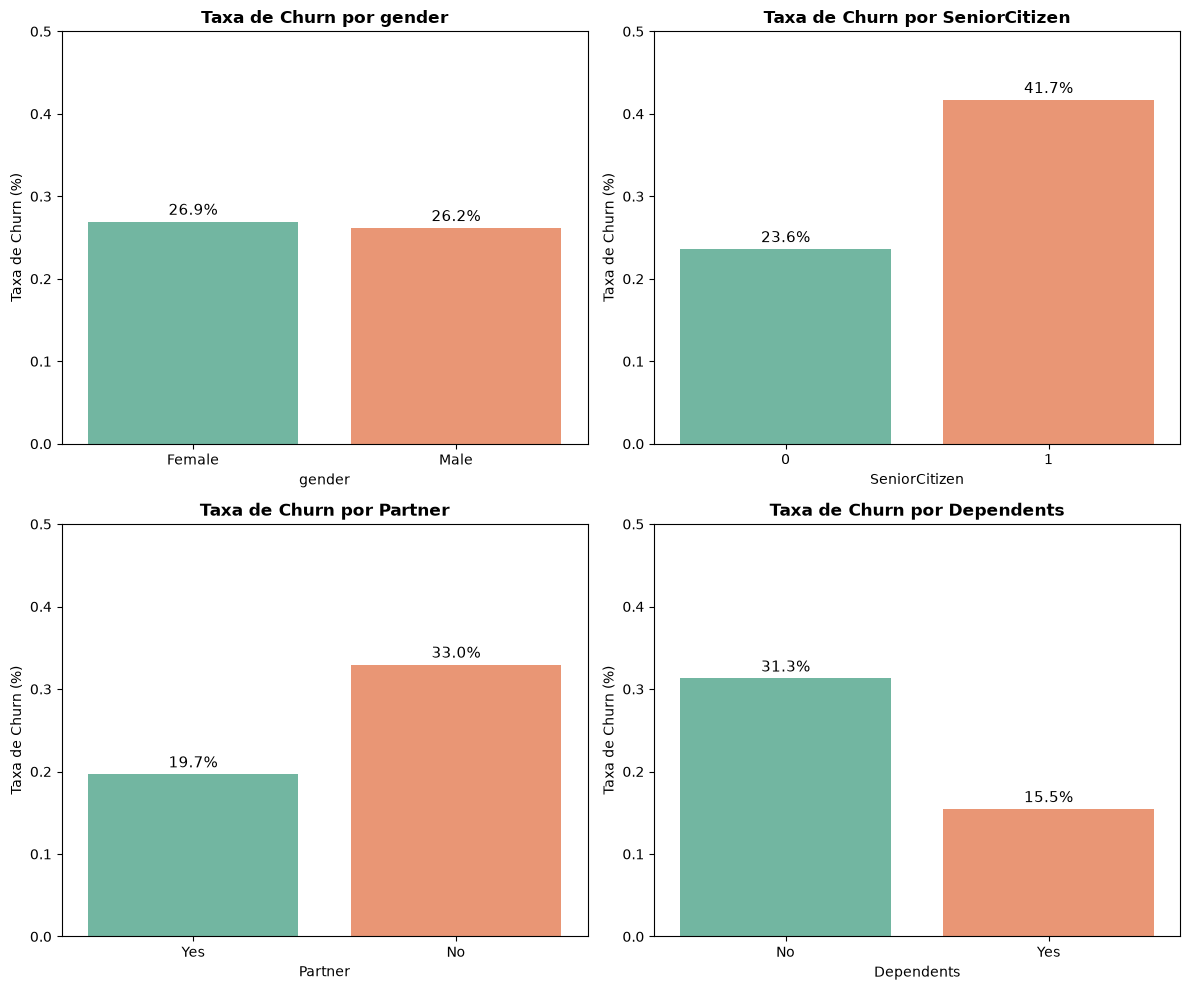

In [26]:
if 'Churn_Rate' not in data.columns:
    data['Churn_Rate'] = data['Churn'].map({'Yes': 1, 'No': 0})

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
variaveis = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

for ax, var in zip(axes.flatten(), variaveis):
    sns.barplot(data=data, x=var, y='Churn_Rate', ax=ax, palette='Set2', errorbar=None)
    
    ax.set_title(f'Taxa de Churn por {var}', fontweight='bold')
    ax.set_ylabel('Taxa de Churn (%)')
    ax.set_ylim(0, 0.5)  
    
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

### 3. Segmentação: Testando a Hipótese da "Estrutura Familiar"
Analisar as colunas de forma isolada é bom, mas combinar dados costuma trazer insights mais profundos. 

Fizemos uma pequena engenharia de recursos (Feature Engineering) e criamos uma nova variável chamada `EstruturaFamiliar`. Se o cliente tiver um parceiro ou dependentes, classificamos como "Com Família"; caso contrário, será classificado como "Sozinho". O objetivo é testar a hipótese de que clientes com mais raízes/laços familiares tendem a ser mais estáveis e cancelar menos.

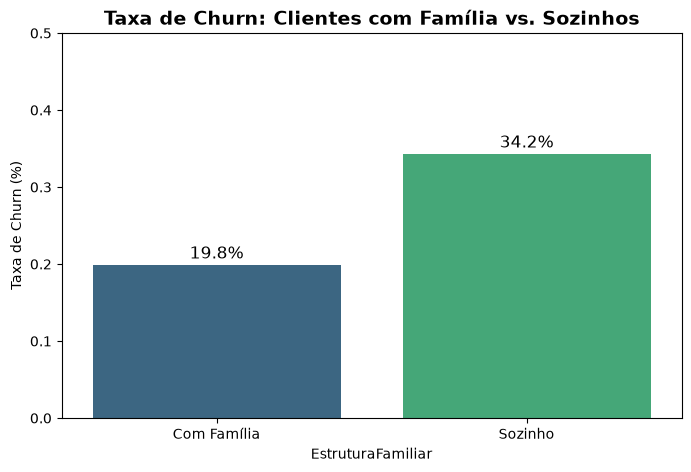

In [107]:
data['EstruturaFamiliar'] = np.where((data['Partner'] == 'Yes') | (data['Dependents'] == 'Yes'), 'Com Família', 'Sozinho')

if 'Churn_Rate' not in data.columns:
    data['Churn_Rate'] = data['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=data, x='EstruturaFamiliar', y='Churn_Rate', palette='viridis', errorbar=None)

plt.title("Taxa de Churn: Clientes com Família vs. Sozinhos", fontsize=14, fontweight='bold')
plt.ylabel("Taxa de Churn (%)")
plt.ylim(0, 0.5)  

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

### A Onda de Cancelamentos: Quando perdemos o cliente?

Diferente de ver apenas a média de tempo, o gráfico de densidade nos mostra o "pulso" dos cancelamentos, revelando exatamente onde está o pico de perdas.

* **O que o gráfico mostra:** A curva de clientes **sem dependentes** tem um pico muito acentuado e concentrado nos primeiros meses de contrato. Depois desse susto inicial, a curva cai e se estabiliza. Já os clientes com dependentes têm uma curva de saída muito mais "espalhada" e suave ao longo dos meses.
* **O que isso significa na prática:** O cliente solteiro/sem filhos não apenas cancela mais, ele cancela **muito rápido**. A janela crítica de retenção para esse grupo é nos 2 ou 3 primeiros meses. Passou dessa fase, o risco despenca. Ações de marketing (como descontos progressivos ou bônus nos 3 primeiros meses) devem focar cirurgicamente aqui.

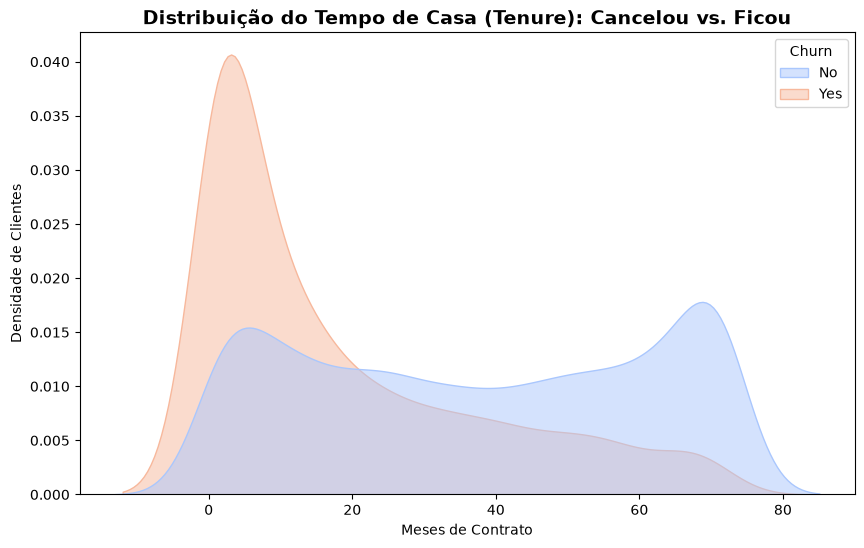

In [28]:
plt.figure(figsize=(10, 6))

# Plotando as curvas de densidade
sns.kdeplot(data=data, x='tenure', hue='Churn', common_norm=False, fill=True, palette='coolwarm', alpha=0.5)

plt.title("Distribuição do Tempo de Casa (Tenure): Cancelou vs. Ficou", fontsize=14, fontweight='bold')
plt.xlabel("Meses de Contrato")
plt.ylabel("Densidade de Clientes")
plt.show()

### 5. Tirando a Prova Real: Validação Estatística
Visualizações são ótimas para levantar suspeitas, mas precisamos ter certeza de que o que estamos vendo não é apenas uma variação aleatória da nossa amostra. 

Para fechar essa etapa demográfica, vamos rodar um **Teste de Qui-Quadrado**. Ele vai validar matematicamente se existe uma relação estatisticamente significativa entre a variável `SeniorCitizen` (ser idoso) e o `Churn`, ou se qualquer diferença nas taxas foi apenas obra do acaso.

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.heatmap(tabela_contingencia, annot=True, fmt='d', cmap='Blues', 
            linewidths=1, linecolor='white', cbar=False)

plt.title("Mapa de Calor: Idosos vs. Churn", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cancelou? (Churn)", fontweight='bold')
plt.ylabel("É Idoso? (SeniorCitizen)", fontweight='bold')
plt.show()

print(f"Estatística Qui-Quadrado (calculada): {chi2:.4f}")
if chi2 > valor_critico:
    print("Resultado: Há uma relação estatisticamente significativa entre ser idoso e o Churn.")
else:
    print("Resultado: Não há evidências suficientes para dizer que ser idoso afeta o Churn (pode ser acaso).")

NameError: name 'tabela_contingencia' is not defined

<Figure size 700x500 with 0 Axes>

### Diagnóstico: O peso do perfil demográfico no Churn

Traduzindo os gráficos em insights de negócio, podemos notar padrões muito claros sobre quem são os clientes que mais cancelam:

**1. Gênero (Gender)**
* **O que vemos:** As taxas de retenção e cancelamento são praticamente idênticas para homens e mulheres.
* **Insight prático:** Gênero não é um fator de decisão para o nosso produto. Não precisamos gastar tempo ou orçamento criando campanhas de retenção segmentadas por sexo.

**2. Idosos (SeniorCitizen)**
* **O que vemos:** Os idosos representam uma fatia pequena da base, mas a proporção de cancelamento dentro desse grupo é visivelmente maior se comparada aos clientes mais jovens.
* **Insight prático:** Temos um ponto de atenção. Esse alto nível de evasão levanta algumas hipóteses para investigar: os planos estão caros para aposentados? A usabilidade dos serviços ou o suporte técnico não estão amigáveis para eles?

**3. Parceiros (Partner)**
* **O que vemos:** Clientes solteiros ou que moram sozinhos apresentam um volume de cancelamento significativamente superior.
* **Insight prático:** A presença de um parceiro traz estabilidade. É possível que os custos da casa sendo divididos façam com que o serviço de internet/telefone pese menos no bolso e se torne mais indispensável para o casal.

**4. Dependentes (Dependents)**
* **O que vemos:** O cenário mais crítico de evasão está entre os clientes sem dependentes. Em contrapartida, aqueles com família/filhos apresentam uma lealdade muito maior à empresa.
* **Insight prático:** Clientes independentes são altamente voláteis e representam nosso maior risco. Se o time de marketing for desenhar estratégias agressivas de fidelização (como descontos nos primeiros meses ou upgrades de velocidade gratuitos), o foco deve ser tentar "segurar" esse público sem dependentes.

# 3. Analises sobre os dados de serviços


### 1. Entendendo os serviços que a empresa mais vende
Nesta etapa buscamos entender o que a empresa, de fato, mais vende. 

Criamos um panorama geral da distribuição dos serviços contratados analisando a presença de telefone (`PhoneService`), o tipo de internet utilizado (`InternetService`) e a adesão aos serviços adicionais. Isso nos nos traz uma visão de como o portifólio está distribuído.

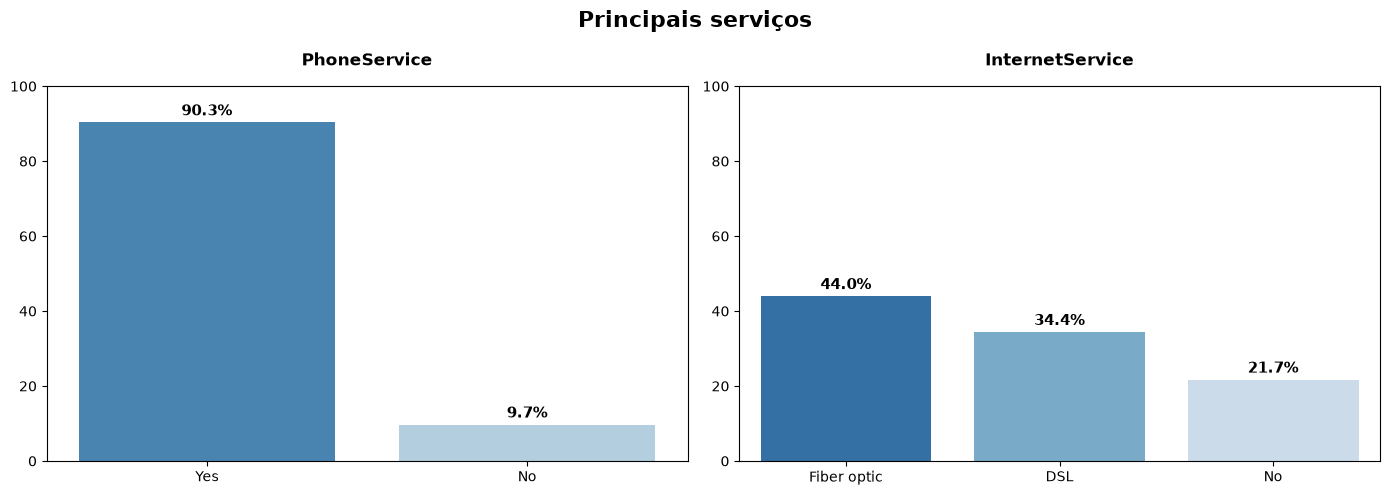

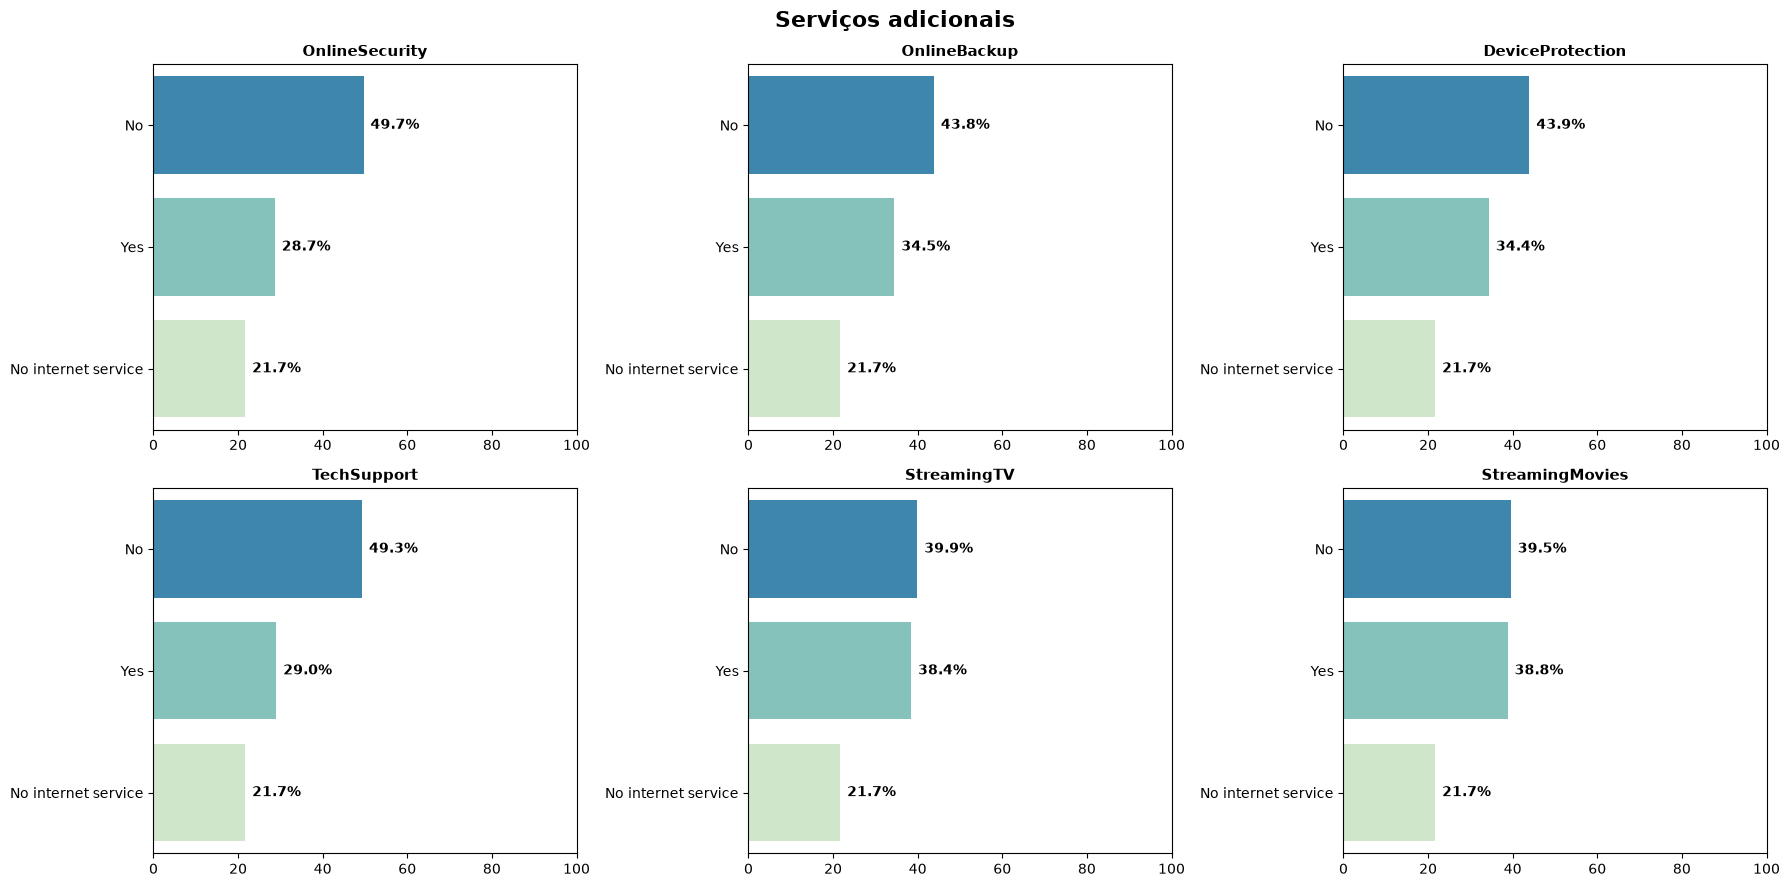

In [94]:
servicos_principais = ['PhoneService', 'InternetService']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(servicos_principais):
    proporcao = data[col].value_counts(normalize=True) * 100
    
    sns.barplot(x=proporcao.index, y=proporcao.values, ax=axes[i], palette="Blues_r")
    
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold', pad=15)
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, 100)
    
    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_height():.1f}%", 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', xytext=(0, 8), 
                         textcoords='offset points', fontsize=11, fontweight='semibold')

plt.suptitle("Principais serviços", fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

servicos_adicionais = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(servicos_adicionais):
    proporcao = data[col].value_counts(normalize=True) * 100
    
    sns.barplot(x=proporcao.values, y=proporcao.index, ax=axes[i], palette="GnBu_r")
    
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].set_xlim(0, 100)
    
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].annotate(f"{width:.1f}%", 
                         (width, p.get_y() + p.get_height() / 2.), 
                         ha='left', va='center', xytext=(5, 0), 
                         textcoords='offset points', fontsize=10, fontweight='semibold')

plt.suptitle("Serviços adicionais", fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()


- **O Telefone:** 90% de adesão, o serviço de telefonia funciona como a porta de entrada dos pacotes da empresa. Planos puramente focados em internet sem linha telefônica são raros.
- **A Fibra Ótica:** Entre os clientes que utilizam internet, a Fibra Ótica é a tecnologia dominante (44.0%), superando as conexões DSL (34.4%).

- **Suporte e Segurança:** `OnlineSecurity` e `TechSupport`, enfrentam forte rejeição. Quase metade da base (perto de 50%) escolheu não contratá-los.
- **Entretenimento:** Os serviços de streaming (`StreamingTV` e `StreamingMovies`) possuem uma divisão equilibrada (quase 40% de adesão para cada um). O cliente da empresa consome bem o entretenimento, mas deixa a segurança digital de lado.

### 2. Cruzamento com `churn`
O próximo passo é tentar identificar onde começam os primeiros sinais de alerta. Nesta etapa, cruzamos as variáveis de serviços diretamente com a taxa de cancelamento (`Churn`). 

O objetivo é descobrir se o cancelamento está distribuído de maneira uniforme ou se existem serviços específicos que estão servindo de gatilho para a saída dos clientes.


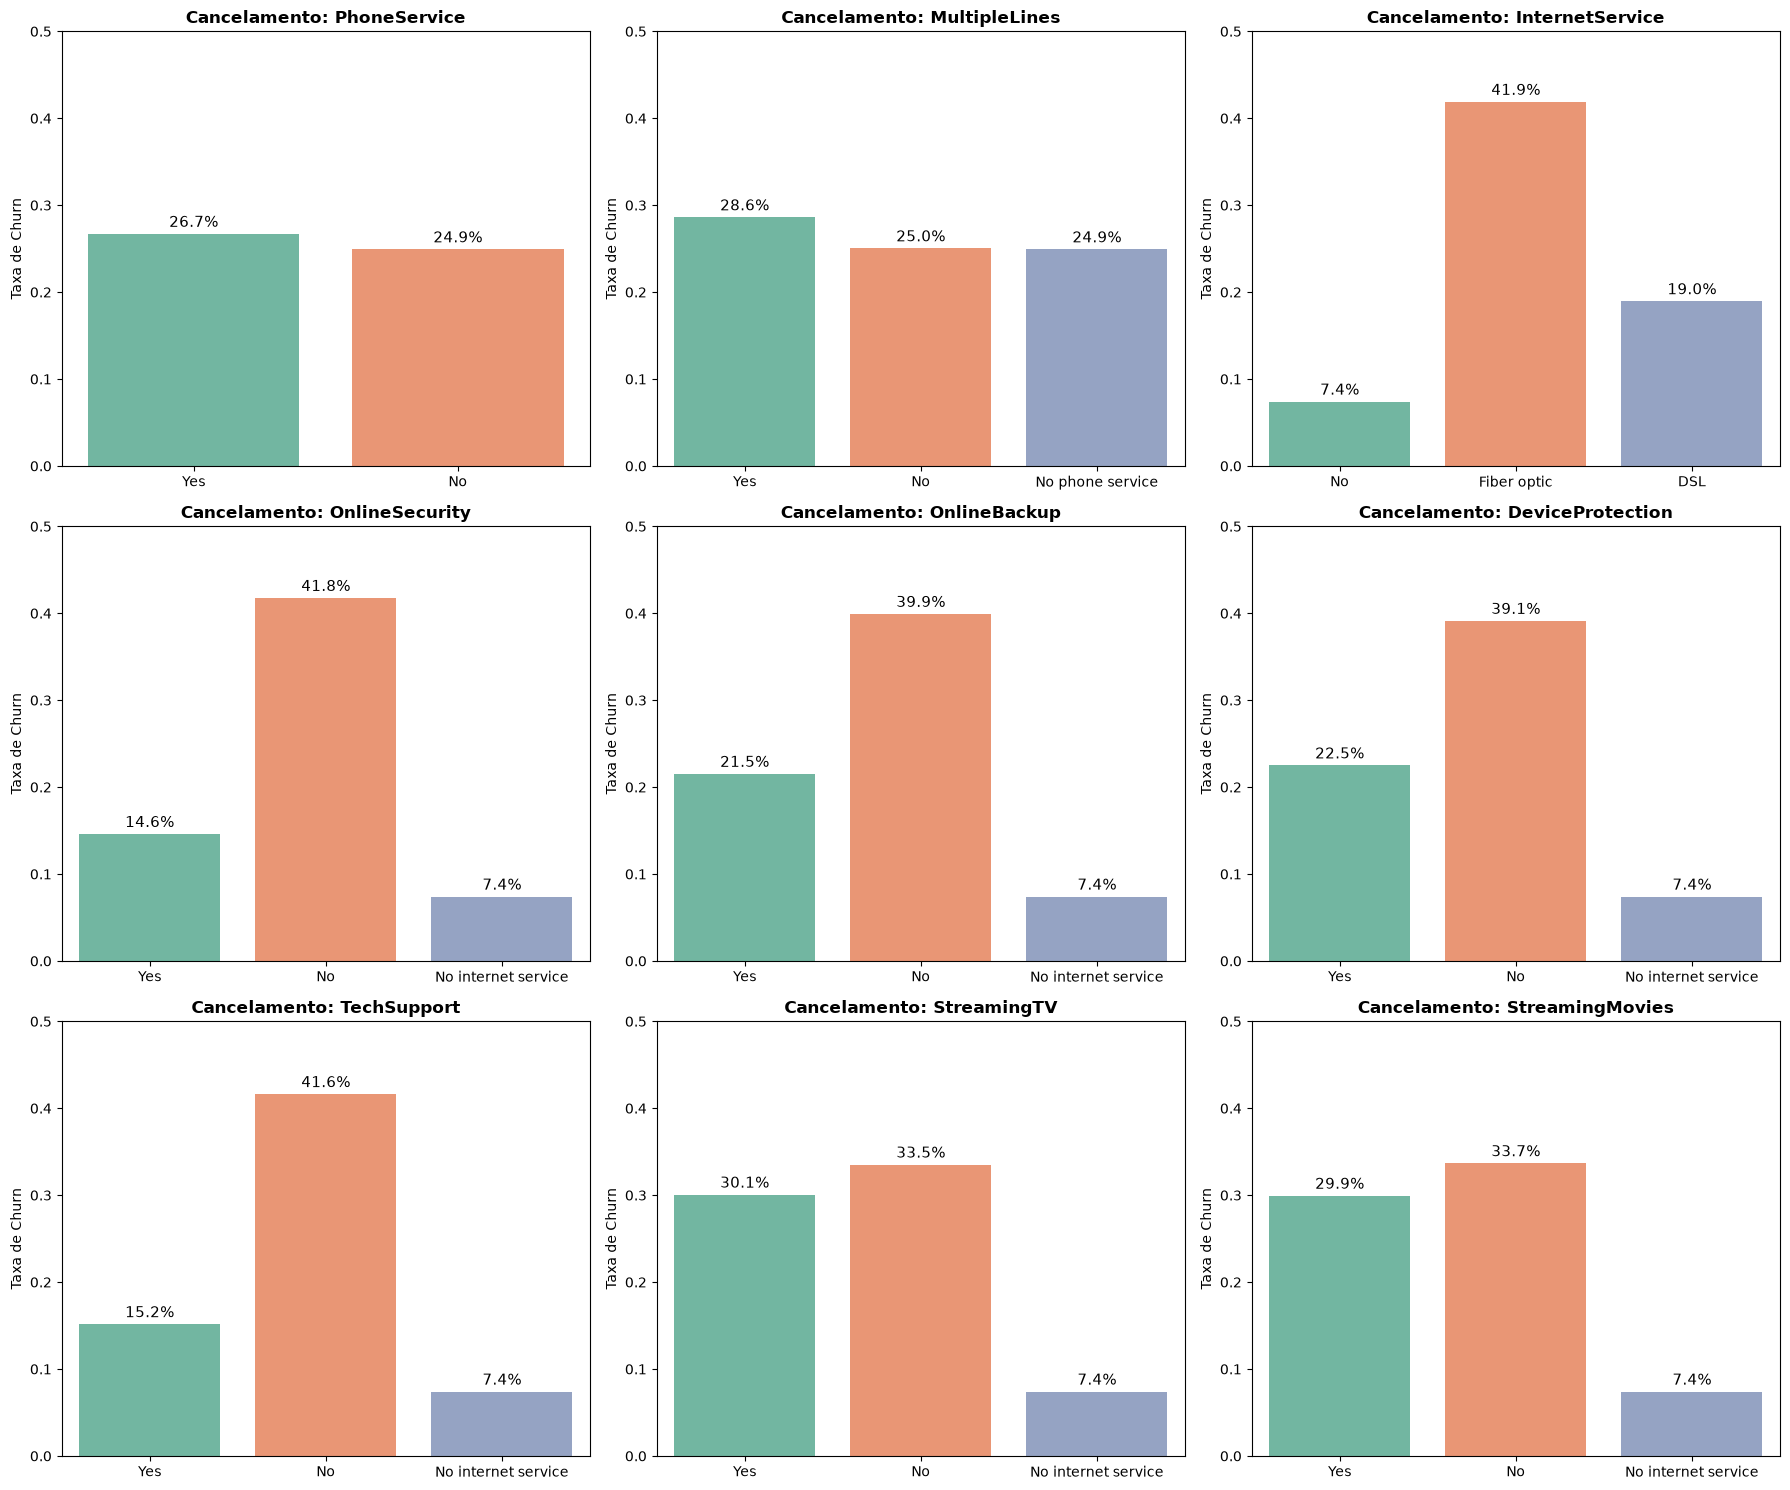

In [95]:
colunas_servicos = [ 
    'PhoneService', 'MultipleLines', 'InternetService', 
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies' 
]

if 'Churn_Rate' not in data.columns: 
    data['Churn_Rate'] = data['Churn'].map({'Yes': 1, 'No': 0})

fig, axes = plt.subplots(3, 3, figsize=(18, 15)) 
axes = axes.flatten() 

for i, servico in enumerate(colunas_servicos):
    valores_unicos = data[servico].dropna().unique()
    ordem_ideal = ['Yes', 'No', 'No internet service', 'No phone service', 'Fiber optic', 'DSL']
    ordem_final = [opcao for opcao in ordem_ideal if opcao in valores_unicos]
    
    sns.barplot(
        data=data, x=servico, y='Churn_Rate', ax=axes[i], 
        palette='Set2', errorbar=None, order=ordem_final
    )
    
    axes[i].set_title(f'Cancelamento: {servico}', fontweight='bold')
    axes[i].set_ylabel('Taxa de Churn')
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, 0.5)
    
    for p in axes[i].patches:
        axes[i].annotate(
            f"{p.get_height():.1%}", 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='baseline', fontsize=11, color='black', 
            xytext=(0, 5), textcoords='offset points'
        )

plt.tight_layout()
plt.show()


- **O Maior Fator de Risco:** A Fibra Ótica registra uma taxa de cancelamento de 41,9%, o que representa mais que o dobro da internet via cabo (DSL, com 19,0%). A maior evasão concentra-se no principal serviço de internet, indicando prováveis falhas na qualidade percebida ou no custo-benefício desse produto.
- **Segurança e Suporte:** Os serviços de `OnlineSecurity`, `OnlineBackup`, `DeviceProtection` e `TechSupport` apresentam comportamento similar. Clientes que não contratam esses adicionais registram taxas de evasão próximas a 40%. Quando os serviços estão ativos, as taxas caem para a faixa de 14% a 22%. A contratação desses serviços sugere uma maior estabilidade do cliente na base.
- **Telefonia e Streaming:** A variação nas taxas de cancelamento nos serviços de telefonia (`PhoneService` e `MultipleLines`) e entretenimento (`StreamingTV` e `StreamingMovies`) é baixa, ficando em torno de 3% a 4% de diferença entre os grupos. Assim, sugere-se que a presença ou ausência destes serviços não é o fator decisivo para a saída do cliente.

### 3. Hipotese dos multiplos pacotes contratados servindo como escudo de cancelamento
Anteriormente, foi identificado que a ausência de serviços de proteção e suporte é um forte gatilho para o cancelamento. Mas o que acontece se o cliente combinar vários desses serviços?

Para aprofundamento, criamos uma nova variável chamada `Qtd_Servicos_Seguranca`. Ela soma quantos desses quatro serviços o cliente possui ativos.

A nossa hipótese a ser testada é: o acúmulo de serviços cria um "escudo de retenção" que reduz a evasão de forma progressiva?


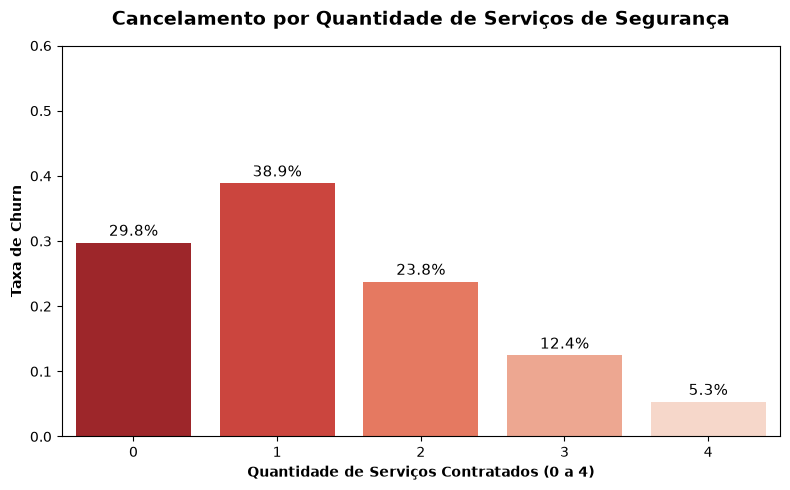

In [96]:
cols_seguranca = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']

data['Qtd_Servicos_Seguranca'] = (data[cols_seguranca] == 'Yes').sum(axis=1)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=data, x='Qtd_Servicos_Seguranca', y='Churn_Rate', palette='Reds_r', errorbar=None)

plt.title("Cancelamento por Quantidade de Serviços de Segurança", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Quantidade de Serviços Contratados (0 a 4)", fontweight='bold')
plt.ylabel("Taxa de Churn", fontweight='bold')
plt.ylim(0, 0.6) 

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1%}", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

- **Pacote Básico é vulnerável:** Clientes que contratam a internet "crua", com zero serviços de proteção extras, apresentam um risco de evasão maior. Fornecer apenas a conexão bruta não gera lealdade.
- **A Queda Progressiva do Risco:** À medida que o cliente adiciona camadas de serviços ao seu plano, o cancelamento cai. Clientes que fecham o pacote de segurança completo (4 serviços) possuem um índice de evasão muito baixo, na casa dos 5%.
- **Insight**: Estratégias para ofertar serviços adicionais para quem já é cliente não devem ser vistas apenas como uma forma de aumentar a receita, mas como forma de fidelização. Oferecer o primeiro serviço de segurança com desconto agressivo ou gratuidade nos meses iniciais pode ser a ação de marketing mais eficiente para reter o cliente a longo prazo.

### 4. Os multiplos serviços revertem a evasão do cliente?
Foi visto que acumular serviços de segurança reduz o cancelamento no geral. Mas será que esse "escudo" perde o efeito com o passar dos anos ou ele garante estabilidade contínua para a empresa?

Realizamos um cruzamento entre o tempo de contrato com a quantidade de serviços adicionais de segurança e suporte para testar se mais pacotes garantem maior estabilidade contínua.

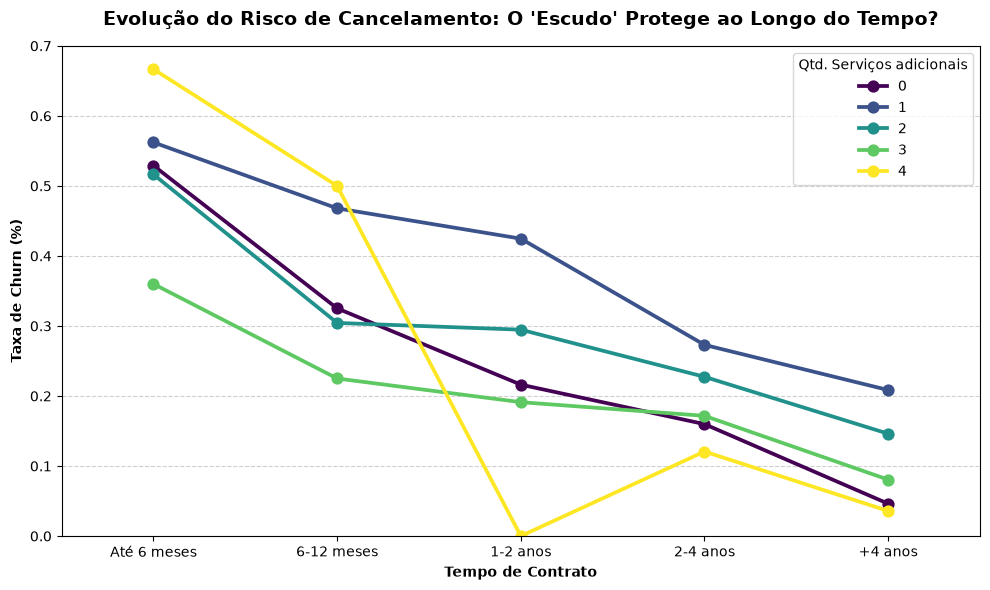

In [103]:
if 'Qtd_Servicos_Seguranca' not in data.columns:
    cols_seguranca = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
    data['Qtd_Servicos_Seguranca'] = (data[cols_seguranca] == 'Yes').sum(axis=1)

if 'Churn_Rate' not in data.columns:
    data['Churn_Rate'] = data['Churn'].map({'Yes': 1, 'No': 0})

bins = [0, 6, 12, 24, 48, 72]
labels = ['Até 6 meses', '6-12 meses', '1-2 anos', '2-4 anos', '+4 anos']
data['Faixa_Tempo'] = pd.cut(data['tenure'], bins=bins, labels=labels)

plt.figure(figsize=(10, 6))
sns.pointplot(data=data, x='Faixa_Tempo', y='Churn_Rate', hue='Qtd_Servicos_Seguranca', 
              palette='viridis', errorbar=None, markers='o')

plt.title("Evolução do Risco de Cancelamento: O 'Escudo' Protege ao Longo do Tempo?", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Taxa de Churn (%)", fontweight='bold')
plt.xlabel("Tempo de Contrato", fontweight='bold')
plt.ylim(0, 0.7)
plt.legend(title='Qtd. Serviços adicionais')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

- **O Choque dos Pacotes:** Clientes com o pacote completo (4 serviços) apresentam uma taxa de evasão crítica nos primeiros 6 meses, caindo de forma radical no período seguinte. Este comportamento sugere que os consumidores que investem em soluções completas logo de início têm expectativas altíssimas; se a experiência técnica falha na fase de adaptação, o cancelamento é quase imediato.   
- **A Fidelização pelo Tempo:** No longo prazo, a diferença entre ter mais pacotes ou básico, quase some. Com 4 anos de contrato, a taxa de cancelamento dos clientes sem serviços adicionais cai a ponto de empatar com a dos clientes "premium" (ambas abaixo dos 5%). Se o cliente sobrevive aos primeiros anos, a inércia consolida a sua permanência.   
- **Insight:** O orçamento de retenção da empresa está a ser mal distribuído se focar apenas em clientes antigos. O perigo também está nos dois primeiros anos. A empresa precisa de um atendimento prioritário focado nos recém-chegados que adquirem pacotes "premium", garantindo que ultrapassam os 6 meses iniciais sem frustrações.

### 5. Validação Estatística do "Escudo" de Serviços
As visualizações anteriores indicaram que o acúmulo de serviços de proteção reduz a evasão de forma drástica.

Um Teste de Qui-Quadrado sobre a nossa variável criada (`Qtd_Servicos_Seguranca`) vai validar se a relação entre o volume de serviços contratados e a decisão de cancelar o contrato é estatisticamente significativa.

In [112]:
from scipy.stats import chi2_contingency

tabela_contingencia_pacote = pd.crosstab(data['Qtd_Servicos_Seguranca'], data['Churn'])

chi2, p_valor, dof, expected = chi2_contingency(tabela_contingencia_pacote)

print(f"Estatística Qui-Quadrado: {chi2:.2f}")
print(f"P-valor: {p_valor:.4e}")

if p_valor < 0.05:
    print("\nHá uma relação estatisticamente comprovada entre a quantidade de serviços de segurança e o Churn.")
else:
    print("\nNão há evidências matemáticas suficientes para afirmar que o volume de serviços afeta o Churn.")

Estatística Qui-Quadrado: 338.97
P-valor: 4.2294e-72

Há uma relação estatisticamente comprovada entre a quantidade de serviços de segurança e o Churn.


### O Peso do Portfólio de Serviços no Churn

Resumindo, foram identificados padrões de como o nosso portfólio afeta a retenção:

**1. A Ameaça no Produto Principal (Fibra Ótica)**
A Fibra Ótica é o serviço de internet mais vendido, mas possui uma taxa de cancelamento muito alta (acima de 40%), concentrada quase totalmente nos primeiros meses de uso.
- **Insight:** O "carro-chefe" financeiro tem um problema crônico de primeira impressão. A empresa precisa auditar o processo de Onboarding.

**2. O "Escudo" de Serviços**
Existe uma relação matemática entre a quantidade de serviços periféricos que o cliente contrata (Suporte Técnico, Backup, Segurança Online, Proteção de Dispositivo) e a sua permanência. A ausência de suporte eleva o cancelamento, enquanto o pacote completo derruba a evasão.
- **Insight:** Vender segurança e suporte não deve ser tratado apenas como receita extra, mas sim como política de fidelização. Oferecer esses serviços com descontos ou embutidos no pacote inicial, é um investimento na retenção.

**3. Entretenimento e Telefonia**
Possuir ou não linha telefônica fixa, TV a cabo ou streaming de filmes não altera o risco de cancelamento de forma significativa.
- **Insight:** Promoções focadas em dar "meses grátis de filmes" para tentar segurar clientes que estão pedindo para cancelar provavelmente teriam baixo efeito. O foco da retenção deve ser **técnico**, não entretenimento.

**4. Fator do tempo**
A longo prazo, a diferença entre o cliente básico e o cliente "premium" desaparece. Se um cliente sobrevive aos 2 primeiros anos, a inércia faz com que ele não cancele mais.
- **Insight:** O orçamento das campanhas de fidelização deve ser alocado para os novos clientes. Criar um "Esquadrão de Boas-Vindas" com atendimento prioritário para quem acabou de assinar mais pacotes é a melhor estratégia para diminuir a perda de receita.